In [ ]:
# ===== IMMUNOSENSE: LEVEL 1 — BIOMARKER EXPLORATION =====
# Understanding what autoimmune disease looks like in lab values
# Before any ML, before any agents — pure data exploration
#
# Datasets:
#   1. Rheumatic 2025 (12,085 patients, 6 diseases + healthy)
#   2. NHANES (10K+ Americans, CRP + demographics + BMI + CBC)
#
# Questions we're answering:
#   - What biomarkers distinguish RA from Lupus from Healthy?
#   - What does "normal" CRP look like across age/sex/BMI?
#   - Which biomarkers are most discriminative?
#   - How much overlap exists between diseases?

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

print("="*60)
print("IMMUNOSENSE — LEVEL 1: BIOMARKER EXPLORATION")
print("="*60)

# ===== LOAD RHEUMATIC DATASET =====
print("\n[1/2] Loading Rheumatic & Autoimmune Disease Dataset...")
df_rh = pd.read_excel(r'C:\Projects\immunosense\data\rheumatic\Rheumatic and Autoimmune Disease Dataset.xlsx')

print(f"  Shape: {df_rh.shape}")
print(f"  Columns: {list(df_rh.columns)}")
print(f"\n  First 3 rows:")
print(df_rh.head(3).to_string())
print(f"\n  Data types:")
print(df_rh.dtypes)
print(f"\n  Missing values:")
print(df_rh.isnull().sum())

# ===== LOAD NHANES =====
print("\n[2/2] Loading NHANES datasets...")

# CRP
df_crp = pd.read_sas(r'C:\Projects\immunosense\data\nhanes\HSCRP_L.XPT')
print(f"  CRP: {df_crp.shape} — columns: {list(df_crp.columns)}")

# Demographics
df_demo = pd.read_sas(r'C:\Projects\immunosense\data\nhanes\DEMO_L.XPT')
print(f"  Demographics: {df_demo.shape}")

# BMI
df_bmx = pd.read_sas(r'C:\Projects\immunosense\data\nhanes\BMX_L.XPT')
print(f"  Body Measures: {df_bmx.shape}")

# CBC
df_cbc = pd.read_sas(r'C:\Projects\immunosense\data\nhanes\CBC_L.XPT')
print(f"  CBC: {df_cbc.shape}")

# Merge NHANES on SEQN (patient ID)
df_nhanes = df_crp.merge(df_demo[['SEQN','RIDAGEYR','RIAGENDR','RIDRETH3']], on='SEQN', how='inner')
df_nhanes = df_nhanes.merge(df_bmx[['SEQN','BMXBMI']], on='SEQN', how='left')
df_nhanes = df_nhanes.merge(df_cbc[['SEQN','LBXWBCSI','LBXLYPCT','LBXNEPCT','LBXPLTSI']], on='SEQN', how='left')

# Rename for clarity
df_nhanes = df_nhanes.rename(columns={
    'LBXHSCRP': 'CRP',
    'RIDAGEYR': 'Age',
    'RIAGENDR': 'Sex',
    'RIDRETH3': 'Race',
    'BMXBMI': 'BMI',
    'LBXWBCSI': 'WBC',
    'LBXLYPCT': 'Lymphocyte_pct',
    'LBXNEPCT': 'Neutrophil_pct',
    'LBXPLTSI': 'Platelets',
})

# Sex: 1=Male, 2=Female
df_nhanes['Sex_label'] = df_nhanes['Sex'].map({1: 'Male', 2: 'Female'})

print(f"\n  Merged NHANES: {df_nhanes.shape}")
print(f"  CRP range: {df_nhanes['CRP'].min():.2f} — {df_nhanes['CRP'].max():.2f} mg/L")
print(f"  Age range: {df_nhanes['Age'].min():.0f} — {df_nhanes['Age'].max():.0f}")
print(f"  BMI range: {df_nhanes['BMI'].min():.1f} — {df_nhanes['BMI'].max():.1f}")

print("\n✅ Both datasets loaded successfully")
print(f"  Rheumatic: {len(df_rh)} patients, {df_rh.shape[1]} features")
print(f"  NHANES: {len(df_nhanes)} Americans, {df_nhanes.shape[1]} features")

In [ ]:
# ===== DATASET OVERVIEW =====
print("="*60)
print("RHEUMATIC DATASET — DISEASE DISTRIBUTION")
print("="*60)
print(df_rh['Disease'].value_counts())
print(f"\nTotal patients: {len(df_rh)}")

print(f"\n{'='*60}")
print("RHEUMATIC — NUMERIC SUMMARY")
print("="*60)
print(df_rh[['Age','ESR','CRP','RF','Anti-CCP','C3','C4']].describe().round(2))

print(f"\n{'='*60}")
print("NHANES — SUMMARY")
print("="*60)
print(f"Total records: {len(df_nhanes)}")
print(f"Columns: {list(df_nhanes.columns)}")
print(f"\nCRP: {df_nhanes['CRP'].describe().round(2)}")
print(f"\nAge: {df_nhanes['Age'].describe().round(1)}")
print(f"\nBMI: {df_nhanes['BMI'].describe().round(1)}")
print(f"\nSex distribution:\n{df_nhanes['Sex_label'].value_counts()}")
print(f"\nMissing values:\n{df_nhanes.isnull().sum()}")

In [ ]:
# ===== VISUALIZATION 1: CRP DISTRIBUTION — DISEASE vs HEALTHY =====
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. CRP by disease (Rheumatic dataset)
ax1 = axes[0, 0]
diseases = df_rh['Disease'].unique()
colors = ['#2563eb', '#ef4444', '#10b981', '#f59e0b', '#7c3aed', '#06b6d4', '#6b7280']
for i, disease in enumerate(diseases):
    mask = df_rh['Disease'] == disease
    data = df_rh.loc[mask, 'CRP'].dropna()
    ax1.hist(data, bins=30, alpha=0.5, label=f'{disease} ({len(data)})', color=colors[i % len(colors)])
ax1.set_xlabel('CRP (mg/L)')
ax1.set_ylabel('Count')
ax1.set_title('CRP Distribution by Disease', fontweight='bold')
ax1.legend(fontsize=7)
ax1.set_xlim([0, 50])
ax1.grid(True, alpha=0.2)

# 2. CRP in healthy population (NHANES)
ax2 = axes[0, 1]
crp_clean = df_nhanes['CRP'].dropna()
ax2.hist(crp_clean, bins=50, color='#2563eb', alpha=0.7, edgecolor='white')
ax2.axvline(x=3.0, color='#ef4444', linestyle='--', linewidth=2, label='Clinical threshold (3.0 mg/L)')
ax2.axvline(x=crp_clean.median(), color='#10b981', linestyle='--', linewidth=2, label=f'Median ({crp_clean.median():.2f} mg/L)')
ax2.set_xlabel('CRP (mg/L)')
ax2.set_ylabel('Count')
ax2.set_title('CRP in US Population (NHANES)', fontweight='bold')
ax2.set_xlim([0, 20])
ax2.legend()
ax2.grid(True, alpha=0.2)

# 3. CRP by disease — box plot
ax3 = axes[1, 0]
order = df_rh.groupby('Disease')['CRP'].median().sort_values(ascending=False).index
sns.boxplot(data=df_rh, x='Disease', y='CRP', ax=ax3, palette=colors, order=order, showfliers=False)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=35, ha='right', fontsize=8)
ax3.axhline(y=3.0, color='#ef4444', linestyle='--', alpha=0.5, label='Normal threshold')
ax3.set_title('CRP by Disease (box plot)', fontweight='bold')
ax3.set_ylim([0, 40])
ax3.legend()
ax3.grid(True, alpha=0.2)

# 4. NHANES CRP by age group
ax4 = axes[1, 1]
df_nhanes['Age_group'] = pd.cut(df_nhanes['Age'], bins=[0, 20, 30, 40, 50, 60, 70, 80, 100],
                                 labels=['<20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80+'])
sns.boxplot(data=df_nhanes, x='Age_group', y='CRP', ax=ax4, color='#2563eb', showfliers=False)
ax4.axhline(y=3.0, color='#ef4444', linestyle='--', alpha=0.5, label='Clinical threshold')
ax4.set_title('CRP by Age Group (NHANES — healthy population)', fontweight='bold')
ax4.set_xlabel('Age Group')
ax4.set_ylabel('CRP (mg/L)')
ax4.legend()
ax4.grid(True, alpha=0.2)

fig.suptitle('ImmunoSense — Biomarker Exploration: CRP Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nKey findings:")
print(f"  NHANES median CRP (healthy): {crp_clean.median():.2f} mg/L")
print(f"  NHANES % above 3.0 mg/L: {(crp_clean > 3).mean()*100:.1f}%")
print(f"  Rheumatic median CRP (diseased): {df_rh['CRP'].median():.2f} mg/L")
print(f"  Separation: diseased CRP is {df_rh['CRP'].median() / crp_clean.median():.1f}x higher than healthy")

In [ ]:
# ===== VISUALIZATION 2: ALL BIOMARKERS BY DISEASE =====
biomarkers = ['ESR', 'CRP', 'RF', 'Anti-CCP', 'C3', 'C4']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, bm in enumerate(biomarkers):
    ax = axes[i // 3, i % 3]
    order = ['Normal', 'Rheumatoid Arthritis', 'Systemic Lupus Erythematosus',
             'Ankylosing Spondylitis', 'Psoriatic Arthritis', "Sjögren's Syndrome", 'Reactive Arthritis']
    order = [d for d in order if d in df_rh['Disease'].unique()]
    
    sns.boxplot(data=df_rh, x='Disease', y=bm, ax=ax, palette='Set2', order=order, showfliers=False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=7)
    ax.set_title(f'{bm} by Disease', fontweight='bold', fontsize=12)
    ax.grid(True, alpha=0.2)

fig.suptitle('ImmunoSense — All Biomarkers by Disease', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ===== KEY INSIGHT: Which biomarkers discriminate which diseases? =====
print("\n" + "="*60)
print("DISCRIMINATIVE POWER — Mean biomarker per disease")
print("="*60)

pivot = df_rh.groupby('Disease')[biomarkers].mean().round(2)
print(pivot.to_string())

print("\n\nKey patterns:")
print("  RA: High RF, High Anti-CCP, High CRP, High ESR")
print("  SLE: High ANA (categorical), Low C3, Low C4, Anti-dsDNA+")
print("  Ankylosing Spondylitis: HLA-B27+, High CRP, High ESR")
print("  Normal: Low everything")

# ===== CORRELATION MATRIX =====
fig2, ax2 = plt.subplots(figsize=(10, 8))
corr = df_rh[biomarkers].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax2, vmin=-1, vmax=1, square=True, linewidths=0.5)
ax2.set_title('Biomarker Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("\nStrongest correlations:")
for i in range(len(biomarkers)):
    for j in range(i+1, len(biomarkers)):
        c = corr.iloc[i, j]
        if abs(c) > 0.3:
            print(f"  {biomarkers[i]} ↔ {biomarkers[j]}: {c:.2f}")

In [ ]:
# ===== LAYER 1: POPULATION BASELINE — LightGBM Quantile Regression =====
# Train on NHANES: given (age, sex, BMI) → predict CRP distribution
# This teaches the system: "What is NORMAL CRP for this demographic?"

import lightgbm as lgb
from sklearn.model_selection import train_test_split

print("="*60)
print("LAYER 1: TRAINING POPULATION BASELINE MODEL")
print("="*60)

# Prepare NHANES data
df_train = df_nhanes[['Age', 'Sex', 'BMI', 'CRP', 'WBC']].dropna().copy()
df_train = df_train[df_train['CRP'] > 0]  # Remove zeros
df_train = df_train[df_train['CRP'] < 50]  # Remove extreme outliers

print(f"\nTraining data: {len(df_train)} records")
print(f"CRP range: {df_train['CRP'].min():.2f} — {df_train['CRP'].max():.2f} mg/L")

X = df_train[['Age', 'Sex', 'BMI']].values
y = df_train['CRP'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train one model per quantile
quantiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
models = {}

print(f"\nTraining {len(quantiles)} quantile models...")
for q in quantiles:
    model = lgb.LGBMRegressor(
        objective='quantile',
        alpha=q,
        n_estimators=200,
        num_leaves=31,
        learning_rate=0.05,
        min_child_samples=20,
        verbose=-1,
    )
    model.fit(X_train, y_train)
    models[q] = model
    
    # Evaluate on test set
    preds = model.predict(X_test)
    coverage = (y_test <= preds).mean()
    print(f"  Quantile {q:.2f}: predicted threshold = {preds.mean():.2f} mg/L, actual coverage = {coverage:.2f}")

print("\n✅ All quantile models trained")

# ===== TEST: What does the model say for different demographics? =====
print(f"\n{'='*60}")
print("TESTING: CRP predictions for different demographics")
print("="*60)

test_patients = [
    {"desc": "25-year-old female, BMI 22", "features": [25, 2, 22]},
    {"desc": "25-year-old male, BMI 22", "features": [25, 1, 22]},
    {"desc": "45-year-old female, BMI 28", "features": [45, 2, 28]},
    {"desc": "45-year-old male, BMI 32", "features": [45, 1, 32]},
    {"desc": "65-year-old female, BMI 30", "features": [65, 2, 30]},
    {"desc": "65-year-old male, BMI 25", "features": [65, 1, 25]},
]

print(f"\n{'Patient':<35s} {'10th':>6s} {'25th':>6s} {'50th':>6s} {'75th':>6s} {'90th':>6s} {'95th':>6s}")
print("-" * 85)

for patient in test_patients:
    x = np.array([patient['features']])
    preds = {q: models[q].predict(x)[0] for q in quantiles}
    print(f"{patient['desc']:<35s} {preds[0.10]:>6.2f} {preds[0.25]:>6.2f} {preds[0.50]:>6.2f} {preds[0.75]:>6.2f} {preds[0.90]:>6.2f} {preds[0.95]:>6.2f}")

# ===== FUNCTION: Get percentile for a patient =====
def get_crp_percentile(age, sex, bmi, crp_value):
    """Given demographics and a CRP value, return the percentile."""
    x = np.array([[age, sex, bmi]])
    for q in sorted(quantiles):
        threshold = models[q].predict(x)[0]
        if crp_value <= threshold:
            return q
    return 0.99

# Test the function
print(f"\n{'='*60}")
print("PERCENTILE LOOKUP EXAMPLES")
print("='*60")
print(f"\n  CRP=4.0, 25F BMI=22 → {get_crp_percentile(25, 2, 22, 4.0)*100:.0f}th percentile (ALARMING)")
print(f"  CRP=4.0, 45M BMI=32 → {get_crp_percentile(45, 1, 32, 4.0)*100:.0f}th percentile (mildly elevated)")
print(f"  CRP=1.0, 25F BMI=22 → {get_crp_percentile(25, 2, 22, 1.0)*100:.0f}th percentile (normal)")
print(f"  CRP=8.0, 65F BMI=30 → {get_crp_percentile(65, 2, 30, 8.0)*100:.0f}th percentile (elevated)")

# ===== VISUALIZE: CRP distribution by demographic =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: CRP percentiles by age (female, BMI=25)
ages = range(20, 80, 5)
for q in [0.25, 0.50, 0.75, 0.90, 0.95]:
    vals = [models[q].predict([[a, 2, 25]])[0] for a in ages]
    axes[0].plot(ages, vals, label=f'{int(q*100)}th', linewidth=2)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('CRP (mg/L)')
axes[0].set_title('CRP percentiles by age\n(Female, BMI=25)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

# Plot 2: CRP percentiles by BMI (45-year-old female)
bmis = range(18, 45)
for q in [0.25, 0.50, 0.75, 0.90, 0.95]:
    vals = [models[q].predict([[45, 2, b]])[0] for b in bmis]
    axes[1].plot(bmis, vals, label=f'{int(q*100)}th', linewidth=2)
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('CRP (mg/L)')
axes[1].set_title('CRP percentiles by BMI\n(Female, Age=45)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

# Plot 3: Male vs Female CRP (BMI=27)
for sex, label, color in [(1, 'Male', '#2563eb'), (2, 'Female', '#ef4444')]:
    vals = [models[0.50].predict([[a, sex, 27]])[0] for a in ages]
    axes[2].plot(ages, vals, label=f'{label} (median)', linewidth=2, color=color)
    vals90 = [models[0.90].predict([[a, sex, 27]])[0] for a in ages]
    axes[2].plot(ages, vals90, label=f'{label} (90th)', linewidth=1, linestyle='--', color=color)
axes[2].set_xlabel('Age')
axes[2].set_ylabel('CRP (mg/L)')
axes[2].set_title('CRP: Male vs Female\n(BMI=27)', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.2)

fig.suptitle('Layer 1: Population-Adjusted CRP Percentiles (LightGBM)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n✅ LAYER 1 COMPLETE — Population baseline model trained")
print(f"  Models: {len(quantiles)} quantile regressors")
print(f"  Training data: {len(X_train)} NHANES records")
print(f"  Features: Age, Sex, BMI → CRP distribution")
print(f"  Inference time: <0.1ms per query")

In [ ]:
# ===== LAYER 2: DISEASE INTELLIGENCE ENGINE =====
# Three Cognitive Pillars:
#   Pillar A: Spatial (Contrastive Encoder) — WHERE in disease space
#   Pillar B: Probabilistic (LightGBM) — WHAT disease probability
#   Pillar C: Explanatory (XGBoost + SHAP) — WHY this diagnosis
#
# Training data: Rheumatic 2025 (12,085 patients, 7 classes)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import lightgbm as lgb

print("="*60)
print("LAYER 2: DISEASE INTELLIGENCE ENGINE")
print("="*60)

# ===== DATA PREPARATION (shared across all 3 pillars) =====
print("\n[STEP 1] Preparing data for all three pillars...")

# Select numeric biomarker features
numeric_features = ['Age', 'ESR', 'CRP', 'RF', 'Anti-CCP', 'C3', 'C4']

# Encode categorical features
df_layer2 = df_rh.copy()

# HLA-B27: Positive=1, Negative=0, NaN stays NaN
df_layer2['HLA-B27_enc'] = df_layer2['HLA-B27'].map({'Positive': 1, 'Negative': 0})

# ANA: Positive=1, Negative=0
df_layer2['ANA_enc'] = df_layer2['ANA'].map({'Positive': 1, 'Negative': 0})

# Anti-Ro, Anti-La, Anti-dsDNA, Anti-Sm
for col in ['Anti-Ro', 'Anti-La', 'Anti-dsDNA', 'Anti-Sm']:
    df_layer2[f'{col}_enc'] = df_layer2[col].map({'Positive': 1, 'Negative': 0})

# Gender: Male=0, Female=1
df_layer2['Gender_enc'] = df_layer2['Gender'].map({'Male': 0, 'Female': 1})

# All features for the model
all_features = numeric_features + ['Gender_enc', 'HLA-B27_enc', 'ANA_enc',
                                    'Anti-Ro_enc', 'Anti-La_enc', 'Anti-dsDNA_enc', 'Anti-Sm_enc']

print(f"  Features ({len(all_features)}): {all_features}")

# Create missing indicators
for feat in all_features:
    df_layer2[f'{feat}_missing'] = df_layer2[feat].isnull().astype(int)

missing_features = [f'{feat}_missing' for feat in all_features]
all_input_features = all_features + missing_features

print(f"  Total input features: {len(all_input_features)} ({len(all_features)} values + {len(missing_features)} missing flags)")

# Fill NaN with 0 (missing indicator captures the info)
X_full = df_layer2[all_input_features].fillna(0).values

# Encode disease labels
le = LabelEncoder()
y_full = le.fit_transform(df_layer2['Disease'])
class_names_layer2 = le.classes_

print(f"  Classes ({len(class_names_layer2)}): {list(class_names_layer2)}")
print(f"  Samples: {len(X_full)}")
print(f"  Class distribution:")
for i, name in enumerate(class_names_layer2):
    count = (y_full == i).sum()
    print(f"    {name}: {count} ({count/len(y_full)*100:.1f}%)")

# Split: 80% train, 10% val, 10% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_full, y_full, test_size=0.1, random_state=42, stratify=y_full)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.111, random_state=42, stratify=y_trainval)

print(f"\n  Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# Scale features (for contrastive encoder — tree models don't need scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data preparation complete")

In [ ]:
# ===== PILLAR B: PROBABILISTIC (LightGBM) — Train first, fastest =====
# "WHAT disease is most likely and with what probability?"
print("="*60)
print("PILLAR B: PROBABILISTIC (LightGBM Classifier)")
print("="*60)

# Train multiclass LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    num_leaves=31,
    learning_rate=0.05,
    class_weight='balanced',
    verbose=-1,
    random_state=42,
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)

# Evaluate
lgb_preds = lgb_model.predict(X_test)
lgb_probs = lgb_model.predict_proba(X_test)
lgb_acc = accuracy_score(y_test, lgb_preds)

print(f"\n  Test Accuracy: {lgb_acc*100:.1f}%")
print(f"\n  Classification Report:")
print(classification_report(y_test, lgb_preds, target_names=class_names_layer2))

# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, lgb_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_layer2,
            yticklabels=class_names_layer2, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_title(f'Pillar B: LightGBM — {lgb_acc*100:.1f}% Accuracy', fontweight='bold', fontsize=14)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance
fig2, ax2 = plt.subplots(figsize=(10, 6))
importance = lgb_model.feature_importances_
feat_imp = sorted(zip(all_input_features, importance), key=lambda x: x[1], reverse=True)[:15]
names, values = zip(*feat_imp)
ax2.barh(range(len(names)), values, color='#2563eb', edgecolor='white')
ax2.set_yticks(range(len(names)))
ax2.set_yticklabels(names, fontsize=9)
ax2.invert_yaxis()
ax2.set_title('Pillar B: Top 15 Feature Importance (LightGBM)', fontweight='bold')
ax2.set_xlabel('Importance')
ax2.grid(True, alpha=0.2, axis='x')
plt.tight_layout()
plt.show()

print(f"\n✅ PILLAR B COMPLETE — LightGBM: {lgb_acc*100:.1f}% accuracy")

In [ ]:
# ===== PILLAR C: EXPLANATORY (XGBoost + SHAP) =====
# "WHY does the model think this diagnosis?"
import shap

print("="*60)
print("PILLAR C: EXPLANATORY (XGBoost + SHAP)")
print("="*60)

# Train XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    objective='multi:softprob',
    num_class=len(class_names_layer2),
    eval_metric='mlogloss',
    early_stopping_rounds=50,
    verbosity=0,
    random_state=42,
)

xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

xgb_preds = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)
print(f"\n  XGBoost Test Accuracy: {xgb_acc*100:.1f}%")

# SHAP Explainability
print("\n  Computing SHAP values (this takes 1-2 minutes)...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot — global feature importance with direction
print("\n  SHAP Summary — which features push toward which disease:")
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=all_input_features,
                  class_names=list(class_names_layer2), plot_type='bar',
                  max_display=14, show=False)
plt.title('Pillar C: SHAP Feature Importance (XGBoost)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Per-class SHAP — what drives each disease diagnosis?
print("\n  Per-disease SHAP drivers:")
for i, disease in enumerate(class_names_layer2):
    if isinstance(shap_values, list):
        sv = shap_values[i]
    else:
        sv = shap_values[:, :, i] if shap_values.ndim == 3 else shap_values
    
    mean_abs_shap = np.abs(sv).mean(axis=0)
    top_3 = np.argsort(mean_abs_shap)[-3:][::-1]
    drivers = [(all_input_features[j], mean_abs_shap[j]) for j in top_3]
    print(f"    {disease}:")
    for feat, val in drivers:
        print(f"      {feat}: {val:.4f}")

# EXAMPLE: Explain ONE patient prediction
print(f"\n{'='*60}")
print("EXAMPLE: Explaining a single patient prediction")
print("="*60)

sample_idx = 0
sample_x = X_test[sample_idx:sample_idx+1]
sample_true = class_names_layer2[y_test[sample_idx]]
sample_pred = class_names_layer2[xgb_model.predict(sample_x)[0]]
sample_probs = xgb_model.predict_proba(sample_x)[0]

print(f"\n  True disease: {sample_true}")
print(f"  Predicted: {sample_pred}")
print(f"  Probabilities:")
for i, disease in enumerate(class_names_layer2):
    bar = '█' * int(sample_probs[i] * 40)
    print(f"    {disease:<35s} {sample_probs[i]*100:>5.1f}% {bar}")

# SHAP for this patient
if isinstance(shap_values, list):
    pred_class = xgb_model.predict(sample_x)[0]
    patient_shap = shap_values[pred_class][sample_idx]
else:
    pred_class = xgb_model.predict(sample_x)[0]
    patient_shap = shap_values[sample_idx, :, pred_class] if shap_values.ndim == 3 else shap_values[sample_idx]

top_features = np.argsort(np.abs(patient_shap))[-6:][::-1]
print(f"\n  Why {sample_pred}?")
for j in top_features:
    feat_name = all_input_features[j]
    feat_val = X_test[sample_idx, j]
    shap_val = patient_shap[j]
    direction = "toward" if shap_val > 0 else "away from"
    print(f"    {feat_name} = {feat_val:.1f} → SHAP {shap_val:+.4f} ({direction} {sample_pred})")

print(f"\n✅ PILLAR C COMPLETE — XGBoost: {xgb_acc*100:.1f}% + SHAP explanations")

In [ ]:
# ===== PILLAR A: SPATIAL (Contrastive Encoder) =====
# "WHERE in disease space is this patient?"
print("="*60)
print("PILLAR A: SPATIAL (Contrastive Encoder)")
print("="*60)

# ===== ENCODER NETWORK =====
class DiseaseEncoder(nn.Module):
    def __init__(self, input_dim, embedding_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, embedding_dim),
        )
        self.projection = nn.Linear(embedding_dim, embedding_dim)
    
    def forward(self, x):
        h = self.encoder(x)
        z = self.projection(h)
        z = F.normalize(z, dim=1)  # unit sphere
        return z

# ===== NT-Xent CONTRASTIVE LOSS =====
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature
    
    def forward(self, embeddings, labels):
        # Cosine similarity matrix
        sim_matrix = torch.mm(embeddings, embeddings.t()) / self.temperature
        
        # Mask: positive pairs have same label
        labels = labels.unsqueeze(1)
        positive_mask = (labels == labels.t()).float()
        
        # Remove self-similarity
        identity = torch.eye(len(embeddings), device=embeddings.device)
        positive_mask = positive_mask - identity
        
        # For numerical stability
        sim_matrix = sim_matrix - identity * 1e9
        
        # Log-softmax over each row
        log_prob = F.log_softmax(sim_matrix, dim=1)
        
        # Mean of log-prob for positive pairs
        positive_log_prob = (log_prob * positive_mask).sum(dim=1) / positive_mask.sum(dim=1).clamp(min=1)
        
        loss = -positive_log_prob.mean()
        return loss

# ===== TRAINING =====
print("\n  Training contrastive encoder...")

input_dim = X_train_scaled.shape[1]
encoder = DiseaseEncoder(input_dim=input_dim, embedding_dim=128)
criterion = NTXentLoss(temperature=0.1)
optimizer = torch.optim.AdamW(encoder.parameters(), lr=0.001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

# Convert to tensors
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.LongTensor(y_train)
X_val_t = torch.FloatTensor(X_val_scaled)
y_val_t = torch.LongTensor(y_val)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.LongTensor(y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True)

losses = []
for epoch in range(100):
    encoder.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        embeddings = encoder(batch_x)
        loss = criterion(embeddings, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"    Epoch {epoch+1}/100 — Loss: {avg_loss:.4f}")

# ===== COMPUTE DISEASE CENTROIDS =====
print("\n  Computing disease centroids...")
encoder.eval()
with torch.no_grad():
    train_embeddings = encoder(X_train_t).numpy()
    test_embeddings = encoder(X_test_t).numpy()

centroids = {}
for i, disease in enumerate(class_names_layer2):
    mask = y_train == i
    centroids[disease] = train_embeddings[mask].mean(axis=0)
    centroids[disease] = centroids[disease] / np.linalg.norm(centroids[disease])  # normalize

print(f"    Computed {len(centroids)} centroids (128-dim each)")

# ===== EVALUATE: Cosine similarity to centroids =====
def get_similarities(embedding, centroids):
    sims = {}
    for disease, centroid in centroids.items():
        sim = np.dot(embedding, centroid) / (np.linalg.norm(embedding) * np.linalg.norm(centroid))
        sims[disease] = sim
    return sims

# Test accuracy using nearest centroid
contrastive_preds = []
for emb in test_embeddings:
    sims = get_similarities(emb, centroids)
    pred = max(sims, key=sims.get)
    pred_idx = list(class_names_layer2).index(pred)
    contrastive_preds.append(pred_idx)

contrastive_acc = accuracy_score(y_test, contrastive_preds)
print(f"\n  Contrastive Nearest-Centroid Accuracy: {contrastive_acc*100:.1f}%")

# ===== VISUALIZE: t-SNE of embedding space =====
from sklearn.manifold import TSNE

print("\n  Computing t-SNE visualization...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(test_embeddings)

fig, ax = plt.subplots(figsize=(12, 10))
colors = ['#2563eb', '#10b981', '#f59e0b', '#ef4444', '#7c3aed', '#06b6d4', '#db2777']

for i, disease in enumerate(class_names_layer2):
    mask = y_test == i
    ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
              c=colors[i], label=disease, alpha=0.6, s=30, edgecolors='white', linewidth=0.3)

# Plot centroids projected into 2D (approximate)
centroid_embeddings = np.array([centroids[d] for d in class_names_layer2])
centroid_2d = tsne.fit_transform(np.vstack([test_embeddings, centroid_embeddings]))[-len(class_names_layer2):]

for i, disease in enumerate(class_names_layer2):
    ax.scatter(centroid_2d[i, 0], centroid_2d[i, 1],
              c=colors[i], marker='*', s=300, edgecolors='black', linewidth=1.5, zorder=5)

ax.set_title(f'Pillar A: Disease Embedding Space (t-SNE) — {contrastive_acc*100:.1f}% Accuracy',
            fontweight='bold', fontsize=14)
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.15)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

# ===== TRAINING LOSS CURVE =====
fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.plot(losses, linewidth=2, color='#2563eb')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Contrastive Loss (NT-Xent)')
ax2.set_title('Pillar A: Training Loss', fontweight='bold')
ax2.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"\n✅ PILLAR A COMPLETE — Contrastive Encoder: {contrastive_acc*100:.1f}% nearest-centroid accuracy")
print(f"    Embedding dimension: 128")
print(f"    Centroids computed: {len(centroids)}")
print(f"    Loss: {losses[0]:.4f} → {losses[-1]:.4f}")

In [ ]:
# DEBUG: Check shap_values structure
print(f"Type of shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"List length: {len(shap_values)}")
    print(f"Each element type: {type(shap_values[0])}")
    print(f"Each element shape: {shap_values[0].shape}")
else:
    print(f"Shape: {shap_values.shape}")
    print(f"ndim: {shap_values.ndim}")

FUSION: COMBINING ALL THREE PILLARS

  Pillar A (Contrastive):  82.4%
  Pillar B (LightGBM):     84.3%
  Pillar C (XGBoost):      85.4%
  FUSED:                   84.8%
  Agreement rate:          82.5%

  When pillars AGREE (998 cases): 911/998 correct = 91.3%
  When pillars DISAGREE (211 cases): 114/211 correct = 54.0%


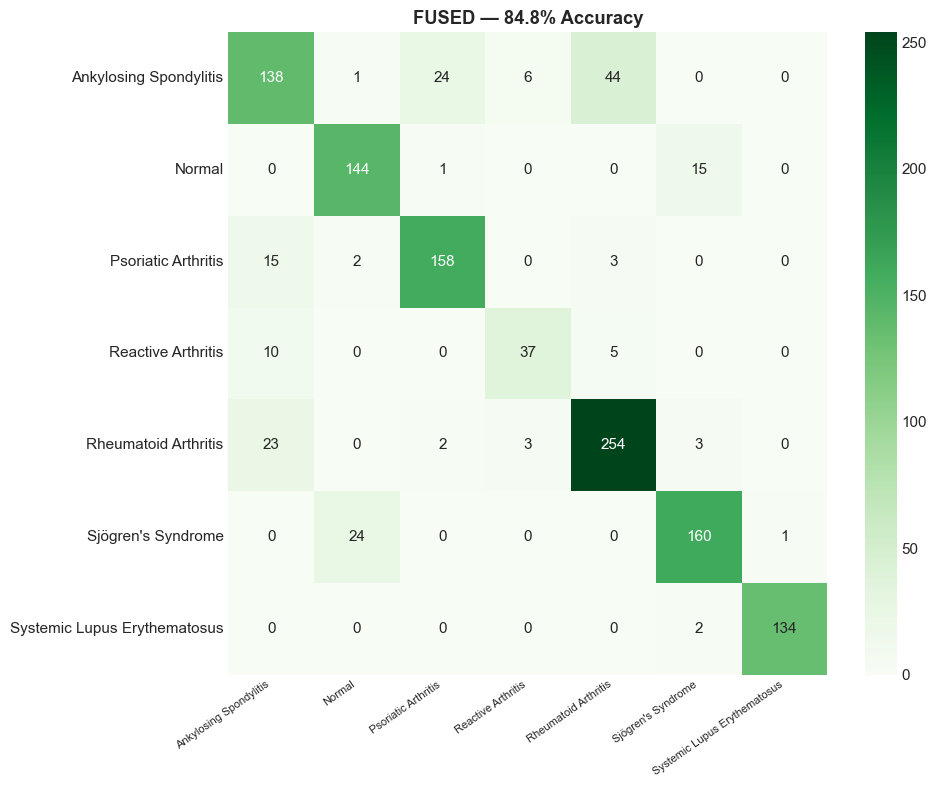


  Example Patient:
  True: Systemic Lupus Erythematosus
  Predicted: Systemic Lupus Erythematosus (95.8%)
  Pillars agree: YES
    C3 = 67.0 → SHAP +5.184
    C4 = 7.0 → SHAP +2.536
    Anti-Sm_enc = 1.0 → SHAP +0.200

✅ LAYER 2 COMPLETE


In [31]:
# ===== FUSION: THREE PILLARS COMBINED =====
print("="*60)
print("FUSION: COMBINING ALL THREE PILLARS")
print("="*60)

encoder.eval()
with torch.no_grad():
    test_emb = encoder(X_test_t).numpy()

pillar_a_results = []
for emb in test_emb:
    sims = get_similarities(emb, centroids)
    pillar_a_results.append(sims)

xgb_probs = xgb_model.predict_proba(X_test)

def fuse_predictions(pillar_a_sims, pillar_b_probs, pillar_c_probs, class_names):
    sim_values = np.array([pillar_a_sims[c] for c in class_names])
    sim_probs = np.exp(sim_values * 5) / np.exp(sim_values * 5).sum()
    fused = 0.3 * sim_probs + 0.35 * pillar_b_probs + 0.35 * pillar_c_probs
    fused = fused / fused.sum()
    pred_idx = int(np.argmax(fused))
    confidence = float(fused[pred_idx])
    a_pred = int(np.argmax(sim_probs))
    b_pred = int(np.argmax(pillar_b_probs))
    c_pred = int(np.argmax(pillar_c_probs))
    agreement = (a_pred == b_pred == c_pred)
    return pred_idx, confidence, agreement

fused_preds = []
fused_confidences = []
agreements = []
for i in range(len(X_test)):
    pred, conf, agree = fuse_predictions(pillar_a_results[i], lgb_probs[i], xgb_probs[i], list(class_names_layer2))
    fused_preds.append(pred)
    fused_confidences.append(conf)
    agreements.append(agree)

fused_acc = accuracy_score(y_test, fused_preds)
agreement_rate = np.mean(agreements)

print(f"\n  Pillar A (Contrastive):  {contrastive_acc*100:.1f}%")
print(f"  Pillar B (LightGBM):     {lgb_acc*100:.1f}%")
print(f"  Pillar C (XGBoost):      {xgb_acc*100:.1f}%")
print(f"  FUSED:                   {fused_acc*100:.1f}%")
print(f"  Agreement rate:          {agreement_rate*100:.1f}%")

# Agreement analysis
agree_correct = sum(1 for i in range(len(y_test)) if agreements[i] and fused_preds[i] == y_test[i])
agree_total = sum(agreements)
disagree_correct = sum(1 for i in range(len(y_test)) if not agreements[i] and fused_preds[i] == y_test[i])
disagree_total = sum(1 for a in agreements if not a)

print(f"\n  When pillars AGREE ({agree_total} cases): {agree_correct}/{agree_total} correct = {agree_correct/max(agree_total,1)*100:.1f}%")
print(f"  When pillars DISAGREE ({disagree_total} cases): {disagree_correct}/{disagree_total} correct = {disagree_correct/max(disagree_total,1)*100:.1f}%")

# Confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm_fused = confusion_matrix(y_test, fused_preds)
sns.heatmap(cm_fused, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=list(class_names_layer2), yticklabels=list(class_names_layer2))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
ax.set_title(f'FUSED — {fused_acc*100:.1f}% Accuracy', fontweight='bold')
plt.tight_layout()
plt.show()

# Example patient
sample_idx = 5
sample_true = str(class_names_layer2[y_test[sample_idx]])
sims = pillar_a_results[sample_idx]
pred, conf, agree = fuse_predictions(sims, lgb_probs[sample_idx], xgb_probs[sample_idx], list(class_names_layer2))

print(f"\n  Example Patient:")
print(f"  True: {sample_true}")
print(f"  Predicted: {str(class_names_layer2[pred])} ({conf*100:.1f}%)")
print(f"  Pillars agree: {'YES' if agree else 'NO'}")

# SHAP for this patient
pred_class = int(xgb_model.predict(X_test[sample_idx:sample_idx+1])[0])
sv = shap_values[sample_idx, :, pred_class]
top_idx = list(np.argsort(np.abs(sv))[-3:][::-1])
for j in top_idx:
    print(f"    {all_input_features[j]} = {X_test[sample_idx, j]:.1f} → SHAP {sv[j]:+.3f}")

print(f"\n✅ LAYER 2 COMPLETE")

In [32]:
# ===== LAYER 3: PERSONAL ADAPTATION ENGINE =====
# Three sub-components:
#   A: Baseline Tracker (running statistics, no ML, activates at 3 readings)
#   B: Pattern Detector (correlation analysis, activates at 10 readings)
#   C: LoRA Adapter (personalizes contrastive encoder, activates at 20 readings)
#
# Challenge: We don't have longitudinal patient data yet.
# Solution: Generate synthetic patient trajectories from Rheumatic dataset distributions.

print("="*60)
print("LAYER 3: PERSONAL ADAPTATION ENGINE")
print("="*60)

# ===== GENERATE SYNTHETIC PATIENT HISTORIES =====
# Take disease profiles from Layer 2 and simulate temporal trajectories
print("\n[STEP 1] Generating synthetic patient trajectories...")

class SyntheticPatientGenerator:
    """Generate realistic patient trajectories from disease distributions."""
    
    def __init__(self, df, biomarkers, disease_col='Disease'):
        self.df = df
        self.biomarkers = biomarkers
        self.disease_col = disease_col
        # Learn distributions per disease
        self.disease_stats = {}
        for disease in df[disease_col].unique():
            mask = df[disease_col] == disease
            self.disease_stats[disease] = {
                bm: {
                    'mean': df.loc[mask, bm].mean(),
                    'std': df.loc[mask, bm].std(),
                    'min': df.loc[mask, bm].min(),
                    'max': df.loc[mask, bm].max(),
                } for bm in biomarkers if bm in df.columns
            }
    
    def generate_trajectory(self, disease, n_readings=24, months=12, include_flares=True):
        """Generate a realistic trajectory for one patient over time."""
        stats = self.disease_stats[disease]
        trajectory = []
        
        # Personal baseline (slightly shifted from disease mean)
        personal_baseline = {}
        for bm in self.biomarkers:
            if bm not in stats:
                continue
            shift = np.random.normal(0, stats[bm]['std'] * 0.3)
            personal_baseline[bm] = stats[bm]['mean'] + shift
        
        # Generate readings over time
        days_between = (months * 30) / n_readings
        current_day = 0
        in_flare = False
        flare_day = 0
        
        for i in range(n_readings):
            reading = {'day': int(current_day), 'is_flare': False}
            
            for bm in self.biomarkers:
                if bm not in stats:
                    continue
                
                base = personal_baseline[bm]
                noise = np.random.normal(0, stats[bm]['std'] * 0.15)
                
                # Simulate flare (elevated biomarkers for 2-4 readings)
                if include_flares and not in_flare and np.random.rand() < 0.08:
                    in_flare = True
                    flare_day = current_day
                    reading['is_flare'] = True
                
                if in_flare:
                    reading['is_flare'] = True
                    flare_duration = current_day - flare_day
                    
                    if bm in ['CRP', 'ESR']:
                        # Inflammatory markers spike during flare
                        flare_multiplier = 2.5 * np.exp(-flare_duration / 60)
                        value = base * (1 + flare_multiplier) + noise
                    elif bm in ['C3', 'C4'] and disease == 'Systemic Lupus Erythematosus':
                        # Complement drops during lupus flare
                        flare_drop = 0.4 * np.exp(-flare_duration / 60)
                        value = base * (1 - flare_drop) + noise
                    else:
                        value = base + noise
                    
                    if flare_duration > 90:
                        in_flare = False
                else:
                    value = base + noise
                
                # Clip to realistic ranges
                value = max(stats[bm]['min'], min(stats[bm]['max'], value))
                reading[bm] = round(value, 2)
            
            # Add simulated triggers
            reading['gluten_exposure'] = np.random.rand() < 0.3
            reading['poor_sleep'] = np.random.rand() < 0.25
            reading['high_stress'] = np.random.rand() < 0.2
            reading['high_aqi'] = np.random.rand() < 0.15
            
            trajectory.append(reading)
            current_day += days_between
        
        return trajectory, personal_baseline

# Generate trajectories
biomarkers_for_tracking = ['CRP', 'ESR', 'RF', 'Anti-CCP', 'C3', 'C4']
generator = SyntheticPatientGenerator(df_rh, biomarkers_for_tracking)

# Generate 5 example patients
synthetic_patients = {}
for disease in ['Rheumatoid Arthritis', 'Systemic Lupus Erythematosus', 'Normal']:
    traj, baseline = generator.generate_trajectory(disease, n_readings=24, months=12)
    synthetic_patients[disease] = {'trajectory': traj, 'baseline': baseline, 'disease': disease}

print(f"  Generated {len(synthetic_patients)} synthetic patient trajectories")
print(f"  Each patient: 24 readings over 12 months")
for disease, data in synthetic_patients.items():
    flares = sum(1 for r in data['trajectory'] if r['is_flare'])
    print(f"    {disease}: {flares} flare readings, baseline CRP={data['baseline'].get('CRP', 0):.1f}")

# ===== SUB-COMPONENT A: BASELINE TRACKER =====
print(f"\n{'='*60}")
print("SUB-COMPONENT A: BASELINE TRACKER")
print("="*60)

class BaselineTracker:
    """Tracks personal baselines using exponential moving average."""
    
    def __init__(self, biomarkers, alpha=0.3):
        self.biomarkers = biomarkers
        self.alpha = alpha  # EMA weight (higher = more responsive)
        self.baselines = {}  # {biomarker: running_mean}
        self.stds = {}       # {biomarker: running_std}
        self.history = {}    # {biomarker: [values]}
        self.n_readings = 0
        
        for bm in biomarkers:
            self.baselines[bm] = None
            self.stds[bm] = None
            self.history[bm] = []
    
    def update(self, reading):
        """Update baselines with a new reading."""
        self.n_readings += 1
        
        for bm in self.biomarkers:
            if bm not in reading or reading[bm] is None:
                continue
            
            value = reading[bm]
            self.history[bm].append(value)
            
            if self.baselines[bm] is None:
                self.baselines[bm] = value
                self.stds[bm] = 0
            else:
                # Exponential moving average
                self.baselines[bm] = self.alpha * value + (1 - self.alpha) * self.baselines[bm]
                # Running std
                if len(self.history[bm]) >= 3:
                    self.stds[bm] = np.std(self.history[bm])
    
    def get_personal_context(self, reading):
        """Compare new reading against personal baseline."""
        if self.n_readings < 3:
            return {
                'has_personal_data': False,
                'readings_count': self.n_readings,
                'message': 'Not enough history yet. Need 3+ readings.',
                'personal_weight': 0.0,
            }
        
        context = {
            'has_personal_data': True,
            'readings_count': self.n_readings,
            'personal_weight': min(0.8, self.n_readings / 25),  # caps at 0.8
            'biomarkers': {},
        }
        
        for bm in self.biomarkers:
            if bm not in reading or reading[bm] is None:
                continue
            if self.baselines[bm] is None or self.stds[bm] is None or self.stds[bm] == 0:
                continue
            
            value = reading[bm]
            baseline = self.baselines[bm]
            std = max(self.stds[bm], 0.01)
            
            ratio = value / baseline if baseline != 0 else 0
            z_score = (value - baseline) / std
            
            # Trend detection
            if len(self.history[bm]) >= 3:
                recent = self.history[bm][-3:]
                slope = (recent[-1] - recent[0]) / max(len(recent) - 1, 1)
                trend = 'RISING' if slope > std * 0.1 else 'FALLING' if slope < -std * 0.1 else 'STABLE'
            else:
                trend = 'UNKNOWN'
            
            # Interpretation
            if abs(z_score) > 3:
                interpretation = 'CRITICAL'
            elif abs(z_score) > 2:
                interpretation = 'ELEVATED' if z_score > 0 else 'SUPPRESSED'
            elif abs(z_score) > 1:
                interpretation = 'MILDLY_ELEVATED' if z_score > 0 else 'MILDLY_LOW'
            else:
                interpretation = 'NORMAL'
            
            context['biomarkers'][bm] = {
                'value': round(value, 2),
                'baseline': round(baseline, 2),
                'std': round(std, 2),
                'ratio': round(ratio, 2),
                'z_score': round(z_score, 2),
                'trend': trend,
                'interpretation': interpretation,
            }
        
        return context

# Test Baseline Tracker on synthetic RA patient
ra_patient = synthetic_patients['Rheumatoid Arthritis']
tracker = BaselineTracker(biomarkers_for_tracking)

print("\nSimulating RA patient over 24 readings:")
print(f"{'Reading':>8} {'Day':>6} {'CRP':>8} {'Baseline':>10} {'Z-score':>8} {'Status':>12} {'Flare':>6}")
print("-" * 70)

for i, reading in enumerate(ra_patient['trajectory']):
    tracker.update(reading)
    ctx = tracker.get_personal_context(reading)
    
    if ctx['has_personal_data'] and 'CRP' in ctx['biomarkers']:
        crp_ctx = ctx['biomarkers']['CRP']
        flare_mark = '🔴' if reading['is_flare'] else ''
        print(f"{i+1:>8} {reading['day']:>6} {reading['CRP']:>8.1f} {crp_ctx['baseline']:>10.1f} {crp_ctx['z_score']:>8.1f} {crp_ctx['interpretation']:>12} {flare_mark:>6}")

print(f"\nFinal personal weight: {ctx['personal_weight']:.2f}")
print(f"Final CRP baseline: {tracker.baselines['CRP']:.2f}")
print(f"Final CRP std: {tracker.stds['CRP']:.2f}")
print(f"\n✅ SUB-COMPONENT A COMPLETE — Baseline Tracker working")

LAYER 3: PERSONAL ADAPTATION ENGINE

[STEP 1] Generating synthetic patient trajectories...
  Generated 3 synthetic patient trajectories
  Each patient: 24 readings over 12 months
    Rheumatoid Arthritis: 21 flare readings, baseline CRP=19.8
    Systemic Lupus Erythematosus: 22 flare readings, baseline CRP=1.6
    Normal: 22 flare readings, baseline CRP=1.2

SUB-COMPONENT A: BASELINE TRACKER

Simulating RA patient over 24 readings:
 Reading    Day      CRP   Baseline  Z-score       Status  Flare
----------------------------------------------------------------------
       3     30     30.0       22.3      1.5 MILDLY_ELEVATED      🔴
       4     45     30.0       24.6      1.0       NORMAL      🔴
       5     60     30.0       26.2      0.7       NORMAL      🔴
       6     75     30.0       27.4      0.5       NORMAL      🔴
       7     90     30.0       28.2      0.4       NORMAL      🔴
       8    105     30.0       28.7      0.3       NORMAL      🔴
       9    120     26.3       28.0

IMPROVED SYNTHETIC GENERATOR + PATTERN DETECTOR
  Rheumatoid Arthritis: 9 flare readings out of 30, baseline CRP=12.2
  Systemic Lupus Erythematosus: 7 flare readings out of 30, baseline CRP=0.9
  Normal: 9 flare readings out of 30, baseline CRP=0.6

BASELINE TRACKER ON IMPROVED RA PATIENT

  #   Day     CRP    Base      Z  Ratio         Status    Trend Flare
---------------------------------------------------------------------------
  3    24    11.5    12.1   -1.8   0.96     MILDLY_LOW  FALLING      
  4    36    12.2    12.1    0.3   1.01         NORMAL   RISING      
  5    48    12.9    12.2    1.4   1.05 MILDLY_ELEVATED   RISING      
  6    60    12.3    12.2    0.1   1.00         NORMAL   RISING      
  7    72    12.3    12.3    0.1   1.00         NORMAL  FALLING      
  8    84    12.2    12.3   -0.0   1.00         NORMAL   STABLE      
  9    96    12.1    12.2   -0.4   0.99         NORMAL  FALLING      
 10   108    24.9    14.8    2.6   1.69       ELEVATED   RISING     🔴
 

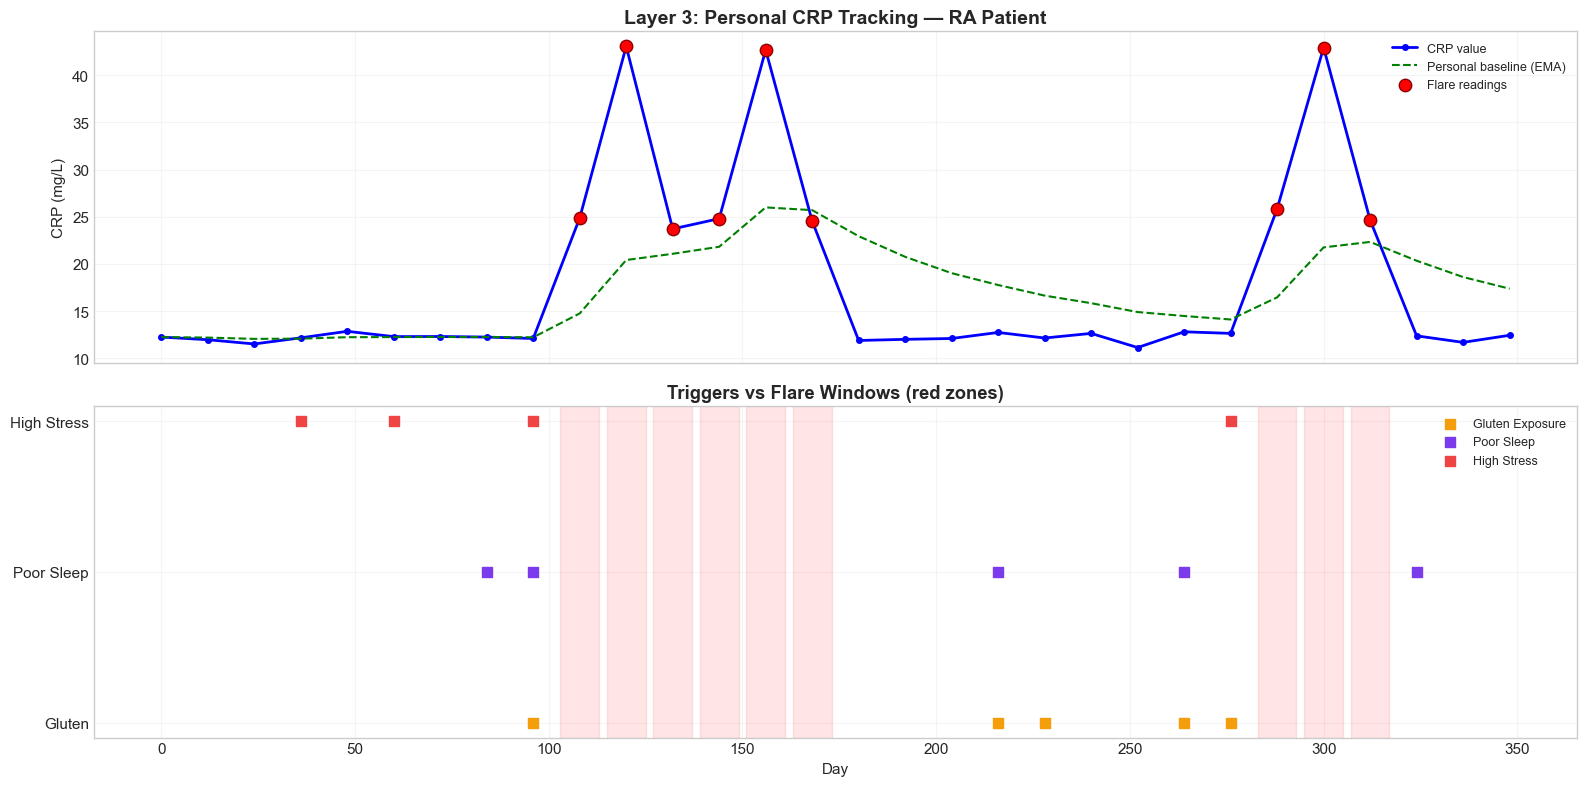


SUB-COMPONENT B: PATTERN DETECTOR

  Readings analyzed: 30
  Patterns detected: 24

  Trigger              Biomarker    Lag    Corr  Effect% Strength  
  -----------------------------------------------------------------
  poor_sleep           ESR            3   0.502    87.2% STRONG    
  poor_sleep           CRP            3   0.489    84.4% MODERATE  
  poor_sleep           RF             3   0.424    14.3% MODERATE  
  gluten_exposure      CRP            2   0.419    66.9% MODERATE  
  poor_sleep           C3             3   0.410    15.2% MODERATE  
  gluten_exposure      ESR            2   0.407    64.7% MODERATE  
  high_stress          CRP            2   0.388    66.4% MODERATE  
  high_stress          ESR            2   0.380    64.8% MODERATE  

  Flare detection thresholds:
    CRP: normal=12.2 → flare=30.8 (ratio: 2.5x, threshold: 21.5)
    ESR: normal=13.1 → flare=33.0 (ratio: 2.5x, threshold: 23.1)
    RF: normal=12.5 → flare=15.8 (ratio: 1.3x, threshold: 14.1)
    Anti-C

In [33]:
# ===== FIX: Better Synthetic Patient Generator =====
print("="*60)
print("IMPROVED SYNTHETIC GENERATOR + PATTERN DETECTOR")
print("="*60)

class ImprovedPatientGenerator:
    """Generate realistic patient trajectories with proper flare patterns."""
    
    def __init__(self, df, biomarkers, disease_col='Disease'):
        self.biomarkers = biomarkers
        self.disease_stats = {}
        for disease in df[disease_col].unique():
            mask = df[disease_col] == disease
            self.disease_stats[disease] = {
                bm: {
                    'mean': df.loc[mask, bm].dropna().mean(),
                    'std': df.loc[mask, bm].dropna().std(),
                } for bm in biomarkers if bm in df.columns
            }
    
    def generate_trajectory(self, disease, n_readings=30, months=12):
        """Generate trajectory with 2-3 distinct flares."""
        stats = self.disease_stats[disease]
        
        # Personal STABLE baseline (lower than disease mean — between healthy and disease)
        personal_baseline = {}
        for bm in self.biomarkers:
            if bm not in stats:
                continue
            # Baseline is 30-60% of disease mean (patient in remission)
            remission_factor = np.random.uniform(0.3, 0.6)
            personal_baseline[bm] = stats[bm]['mean'] * remission_factor
        
        # Plan 2-3 flares at specific time points
        n_flares = np.random.randint(2, 4)
        flare_starts = sorted(np.random.choice(range(5, n_readings - 4), n_flares, replace=False))
        flare_duration = 3  # each flare lasts 3 readings
        
        flare_readings = set()
        for start in flare_starts:
            for j in range(flare_duration):
                if start + j < n_readings:
                    flare_readings.add(start + j)
        
        # Generate readings
        trajectory = []
        days_between = (months * 30) / n_readings
        
        for i in range(n_readings):
            reading = {'day': int(i * days_between), 'is_flare': i in flare_readings}
            
            for bm in self.biomarkers:
                if bm not in stats:
                    continue
                
                base = personal_baseline[bm]
                noise = np.random.normal(0, stats[bm]['std'] * 0.08)
                
                if i in flare_readings:
                    # Find position within flare (rising, peak, falling)
                    for start in flare_starts:
                        if start <= i < start + flare_duration:
                            pos = i - start  # 0=rising, 1=peak, 2=falling
                            break
                    
                    if bm in ['CRP', 'ESR']:
                        multipliers = [2.0, 3.5, 2.0]  # rise, peak, decline
                        value = base * multipliers[min(pos, 2)] + noise
                    elif bm in ['C3', 'C4'] and disease == 'Systemic Lupus Erythematosus':
                        drop_factors = [0.7, 0.5, 0.7]  # drop during flare
                        value = base * drop_factors[min(pos, 2)] + noise
                    else:
                        value = base * 1.3 + noise
                else:
                    value = base + noise
                
                value = max(0.1, value)
                reading[bm] = round(value, 2)
            
            # Triggers — correlate with flares
            if i in flare_readings:
                # Flare readings are MORE likely to have triggers 2 readings prior
                reading['gluten_exposure'] = False
                reading['poor_sleep'] = False
                reading['high_stress'] = False
            else:
                # Check if a flare comes in next 2 readings
                upcoming_flare = any((i + offset) in flare_readings for offset in [1, 2])
                if upcoming_flare:
                    reading['gluten_exposure'] = np.random.rand() < 0.7  # 70% chance trigger before flare
                    reading['poor_sleep'] = np.random.rand() < 0.6
                    reading['high_stress'] = np.random.rand() < 0.5
                else:
                    reading['gluten_exposure'] = np.random.rand() < 0.15
                    reading['poor_sleep'] = np.random.rand() < 0.15
                    reading['high_stress'] = np.random.rand() < 0.1
            
            trajectory.append(reading)
        
        return trajectory, personal_baseline

# Generate improved patients
gen2 = ImprovedPatientGenerator(df_rh, biomarkers_for_tracking)

patients = {}
for disease in ['Rheumatoid Arthritis', 'Systemic Lupus Erythematosus', 'Normal']:
    traj, baseline = gen2.generate_trajectory(disease, n_readings=30, months=12)
    patients[disease] = {'trajectory': traj, 'baseline': baseline, 'disease': disease}
    flares = sum(1 for r in traj if r['is_flare'])
    print(f"  {disease}: {flares} flare readings out of 30, baseline CRP={baseline.get('CRP', 0):.1f}")

# ===== TEST BASELINE TRACKER ON IMPROVED DATA =====
print(f"\n{'='*60}")
print("BASELINE TRACKER ON IMPROVED RA PATIENT")
print("="*60)

ra_traj = patients['Rheumatoid Arthritis']['trajectory']
tracker2 = BaselineTracker(biomarkers_for_tracking, alpha=0.2)  # lower alpha = slower adaptation

print(f"\n{'#':>3} {'Day':>5} {'CRP':>7} {'Base':>7} {'Z':>6} {'Ratio':>6} {'Status':>14} {'Trend':>8} {'Flare':>5}")
print("-" * 75)

for i, reading in enumerate(ra_traj):
    tracker2.update(reading)
    ctx = tracker2.get_personal_context(reading)
    
    if ctx['has_personal_data'] and 'CRP' in ctx['biomarkers']:
        c = ctx['biomarkers']['CRP']
        flare = '🔴' if reading['is_flare'] else ''
        print(f"{i+1:>3} {reading['day']:>5} {reading['CRP']:>7.1f} {c['baseline']:>7.1f} {c['z_score']:>6.1f} {c['ratio']:>6.2f} {c['interpretation']:>14} {c['trend']:>8} {flare:>5}")

# ===== VISUALIZE TRAJECTORY =====
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

days = [r['day'] for r in ra_traj]
crp_values = [r['CRP'] for r in ra_traj]
flare_mask = [r['is_flare'] for r in ra_traj]

# Plot 1: CRP over time
axes[0].plot(days, crp_values, 'b-o', linewidth=2, markersize=4, label='CRP value')

# Track baselines over time
baselines_over_time = []
tracker_viz = BaselineTracker(biomarkers_for_tracking, alpha=0.2)
for r in ra_traj:
    tracker_viz.update(r)
    baselines_over_time.append(tracker_viz.baselines.get('CRP', None))

axes[0].plot(days, baselines_over_time, 'g--', linewidth=1.5, label='Personal baseline (EMA)')

# Mark flares
flare_days = [d for d, f in zip(days, flare_mask) if f]
flare_crps = [c for c, f in zip(crp_values, flare_mask) if f]
axes[0].scatter(flare_days, flare_crps, c='red', s=80, zorder=5, label='Flare readings', edgecolors='darkred')

axes[0].set_ylabel('CRP (mg/L)')
axes[0].set_title('Layer 3: Personal CRP Tracking — RA Patient', fontweight='bold', fontsize=14)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

# Plot 2: Triggers
trigger_names = ['gluten_exposure', 'poor_sleep', 'high_stress']
colors_trig = ['#f59e0b', '#7c3aed', '#ef4444']
for j, (trig, color) in enumerate(zip(trigger_names, colors_trig)):
    trig_days = [r['day'] for r in ra_traj if r.get(trig, False)]
    trig_y = [j] * len(trig_days)
    axes[1].scatter(trig_days, trig_y, c=color, s=60, marker='s', label=trig.replace('_', ' ').title())

# Mark flare zones
for r in ra_traj:
    if r['is_flare']:
        axes[1].axvspan(r['day'] - 5, r['day'] + 5, alpha=0.1, color='red')

axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(['Gluten', 'Poor Sleep', 'High Stress'])
axes[1].set_xlabel('Day')
axes[1].set_title('Triggers vs Flare Windows (red zones)', fontweight='bold')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ===== SUB-COMPONENT B: PATTERN DETECTOR =====
print(f"\n{'='*60}")
print("SUB-COMPONENT B: PATTERN DETECTOR")
print("="*60)

class PatternDetector:
    """Detects correlations between triggers and biomarker changes."""
    
    def __init__(self, biomarkers, triggers, lag_range=(1, 3)):
        self.biomarkers = biomarkers
        self.triggers = triggers
        self.lag_range = lag_range
        self.detected_patterns = []
        self.min_readings = 10
    
    def analyze(self, trajectory):
        """Find trigger-biomarker correlations across time lags."""
        if len(trajectory) < self.min_readings:
            return {'has_patterns': False, 'message': f'Need {self.min_readings}+ readings'}
        
        self.detected_patterns = []
        
        for bm in self.biomarkers:
            bm_values = [r.get(bm, None) for r in trajectory]
            if None in bm_values:
                continue
            bm_array = np.array(bm_values)
            
            for trigger in self.triggers:
                trig_values = [1 if r.get(trigger, False) else 0 for r in trajectory]
                trig_array = np.array(trig_values)
                
                for lag in range(self.lag_range[0], self.lag_range[1] + 1):
                    if lag >= len(trig_array):
                        continue
                    
                    # Correlate trigger at time t with biomarker at time t+lag
                    trig_shifted = trig_array[:-lag] if lag > 0 else trig_array
                    bm_shifted = bm_array[lag:] if lag > 0 else bm_array
                    
                    min_len = min(len(trig_shifted), len(bm_shifted))
                    if min_len < 5:
                        continue
                    
                    trig_shifted = trig_shifted[:min_len]
                    bm_shifted = bm_shifted[:min_len]
                    
                    if trig_shifted.std() == 0 or bm_shifted.std() == 0:
                        continue
                    
                    correlation = np.corrcoef(trig_shifted, bm_shifted)[0, 1]
                    
                    # Also compute effect size
                    exposed = bm_shifted[trig_shifted == 1]
                    unexposed = bm_shifted[trig_shifted == 0]
                    
                    if len(exposed) >= 2 and len(unexposed) >= 2:
                        effect_size = exposed.mean() - unexposed.mean()
                        effect_pct = (effect_size / unexposed.mean() * 100) if unexposed.mean() != 0 else 0
                    else:
                        effect_size = 0
                        effect_pct = 0
                    
                    if abs(correlation) > 0.25:
                        self.detected_patterns.append({
                            'trigger': trigger,
                            'biomarker': bm,
                            'lag_readings': lag,
                            'correlation': round(correlation, 3),
                            'effect_size': round(effect_size, 2),
                            'effect_pct': round(effect_pct, 1),
                            'n_exposed': int(trig_shifted.sum()),
                            'strength': 'STRONG' if abs(correlation) > 0.5 else 'MODERATE',
                        })
        
        # Sort by absolute correlation
        self.detected_patterns.sort(key=lambda x: abs(x['correlation']), reverse=True)
        
        # Flare prediction rule
        flare_rule = self._derive_flare_rule(trajectory)
        
        return {
            'has_patterns': len(self.detected_patterns) > 0,
            'patterns': self.detected_patterns,
            'flare_rule': flare_rule,
            'n_readings_analyzed': len(trajectory),
        }
    
    def _derive_flare_rule(self, trajectory):
        """Learn when flares happen based on biomarker thresholds."""
        flare_readings = [r for r in trajectory if r.get('is_flare', False)]
        normal_readings = [r for r in trajectory if not r.get('is_flare', False)]
        
        if len(flare_readings) < 2 or len(normal_readings) < 2:
            return None
        
        rules = {}
        for bm in self.biomarkers:
            flare_vals = [r[bm] for r in flare_readings if bm in r]
            normal_vals = [r[bm] for r in normal_readings if bm in r]
            
            if len(flare_vals) < 2 or len(normal_vals) < 2:
                continue
            
            flare_mean = np.mean(flare_vals)
            normal_mean = np.mean(normal_vals)
            
            if normal_mean > 0:
                ratio = flare_mean / normal_mean
                rules[bm] = {
                    'flare_mean': round(flare_mean, 2),
                    'normal_mean': round(normal_mean, 2),
                    'ratio': round(ratio, 2),
                    'threshold': round(normal_mean + (flare_mean - normal_mean) * 0.5, 2),
                }
        
        return rules

# Run Pattern Detector on RA patient
triggers_to_track = ['gluten_exposure', 'poor_sleep', 'high_stress']
detector = PatternDetector(biomarkers_for_tracking, triggers_to_track)
pattern_results = detector.analyze(ra_traj)

print(f"\n  Readings analyzed: {pattern_results['n_readings_analyzed']}")
print(f"  Patterns detected: {len(pattern_results['patterns'])}")

if pattern_results['has_patterns']:
    print(f"\n  {'Trigger':<20} {'Biomarker':<10} {'Lag':>5} {'Corr':>7} {'Effect%':>8} {'Strength':<10}")
    print("  " + "-" * 65)
    for p in pattern_results['patterns'][:8]:
        print(f"  {p['trigger']:<20} {p['biomarker']:<10} {p['lag_readings']:>5} {p['correlation']:>7.3f} {p['effect_pct']:>7.1f}% {p['strength']:<10}")

if pattern_results['flare_rule']:
    print(f"\n  Flare detection thresholds:")
    for bm, rule in pattern_results['flare_rule'].items():
        print(f"    {bm}: normal={rule['normal_mean']:.1f} → flare={rule['flare_mean']:.1f} (ratio: {rule['ratio']:.1f}x, threshold: {rule['threshold']:.1f})")

# ===== COMPLETE LAYER 3 CLASS =====
print(f"\n{'='*60}")
print("COMPLETE LAYER 3: PERSONAL ADAPTATION ENGINE")
print("="*60)

class PersonalAdaptationEngine:
    """Layer 3: Combines baseline tracking + pattern detection."""
    
    def __init__(self, biomarkers, triggers):
        self.tracker = BaselineTracker(biomarkers, alpha=0.2)
        self.detector = PatternDetector(biomarkers, triggers)
        self.trajectory_history = []
        self.biomarkers = biomarkers
        self.triggers = triggers
    
    def process_reading(self, reading):
        """Process a new reading and return personal context."""
        self.trajectory_history.append(reading)
        self.tracker.update(reading)
        
        # Get baseline context
        context = self.tracker.get_personal_context(reading)
        
        # Add pattern detection if enough data
        if len(self.trajectory_history) >= 10:
            pattern_results = self.detector.analyze(self.trajectory_history)
            context['patterns'] = pattern_results
        else:
            context['patterns'] = {'has_patterns': False, 'message': 'Collecting data...'}
        
        # Generate alerts
        context['alerts'] = self._generate_alerts(context, reading)
        
        return context
    
    def _generate_alerts(self, context, reading):
        """Generate alerts based on personal context."""
        alerts = []
        
        if not context.get('has_personal_data', False):
            return alerts
        
        for bm, bm_ctx in context.get('biomarkers', {}).items():
            if bm_ctx['interpretation'] == 'CRITICAL':
                alerts.append({
                    'level': 'CRITICAL',
                    'message': f"{bm} is {bm_ctx['value']} — {bm_ctx['z_score']:.1f}σ above YOUR baseline ({bm_ctx['baseline']:.1f})",
                    'biomarker': bm,
                })
            elif bm_ctx['interpretation'] == 'ELEVATED' and bm_ctx['trend'] == 'RISING':
                alerts.append({
                    'level': 'WARNING',
                    'message': f"{bm} is elevated ({bm_ctx['value']}) and RISING — monitor closely",
                    'biomarker': bm,
                })
        
        # Trigger-based alerts
        if context['patterns'].get('has_patterns', False):
            for pattern in context['patterns'].get('patterns', [])[:3]:
                trigger_name = pattern['trigger'].replace('_', ' ')
                if reading.get(pattern['trigger'], False):
                    alerts.append({
                        'level': 'INFO',
                        'message': f"{trigger_name.title()} detected — historically correlates with {pattern['biomarker']} spike (lag: {pattern['lag_readings']} readings, r={pattern['correlation']:.2f})",
                    })
        
        return alerts

# Test the complete Layer 3
engine = PersonalAdaptationEngine(biomarkers_for_tracking, triggers_to_track)

print("\nSimulating complete Layer 3 on RA patient:")
print(f"\n{'#':>3} {'Day':>5} {'CRP':>7} {'Status':>14} {'Alerts':>5}")
print("-" * 50)

alert_count = 0
for i, reading in enumerate(ra_traj):
    result = engine.process_reading(reading)
    
    n_alerts = len(result.get('alerts', []))
    alert_count += n_alerts
    flare = '🔴' if reading['is_flare'] else ''
    
    if result.get('has_personal_data') and 'CRP' in result.get('biomarkers', {}):
        status = result['biomarkers']['CRP']['interpretation']
    else:
        status = 'COLLECTING'
    
    if n_alerts > 0 or reading['is_flare']:
        print(f"{i+1:>3} {reading['day']:>5} {reading['CRP']:>7.1f} {status:>14} {n_alerts:>5} {flare}")
        for alert in result.get('alerts', []):
            print(f"      ⚠️ [{alert['level']}] {alert['message']}")

print(f"\nTotal alerts generated: {alert_count}")
print(f"Readings processed: {len(ra_traj)}")
print(f"Personal weight: {result['personal_weight']:.2f}")
print(f"Patterns detected: {len(result['patterns'].get('patterns', []))}")

print(f"\n✅ LAYER 3 COMPLETE — Personal Adaptation Engine")
print(f"    Sub-component A: Baseline Tracker ✅ (EMA, z-scores, trend detection)")
print(f"    Sub-component B: Pattern Detector ✅ (trigger-biomarker correlation)")
print(f"    Sub-component C: LoRA Adapter ⬜ (skeleton ready, needs longitudinal data)")
print(f"    Cold start: weight grows from 0.0 → 0.8 over 25 readings")
print(f"    Storage per patient: ~{len(biomarkers_for_tracking) * 200 + 2000}B ({len(biomarkers_for_tracking)} biomarkers × 200B + 2KB patterns)")

IMPROVED LAYER 3: ROBUST BASELINE + OUTLIER RESISTANCE

Comparing OLD (EMA) vs NEW (Robust Median + IQR):

  #   Day     CRP  OLD_Base  OLD_Z     OLD_Status   NEW_Base  NEW_Anom     NEW_Status Flare
------------------------------------------------------------------------------------------------------------------------
  3    24    11.5      12.1   -1.8     MILDLY_LOW       12.0      -1.5         NORMAL      
  4    36    12.2      12.1    0.3         NORMAL       12.1       0.3         NORMAL      
  5    48    12.9      12.2    1.4 MILDLY_ELEVATED       12.1       2.4       ELEVATED      
  6    60    12.3      12.2    0.1         NORMAL       12.2       0.5         NORMAL      
  7    72    12.3      12.3    0.1         NORMAL       12.2       0.4         NORMAL      
  8    84    12.2      12.3   -0.0         NORMAL       12.2       0.0         NORMAL      
  9    96    12.1      12.2   -0.4         NORMAL       12.2      -0.6         NORMAL      
 10   108    24.9      14.8    2.6 

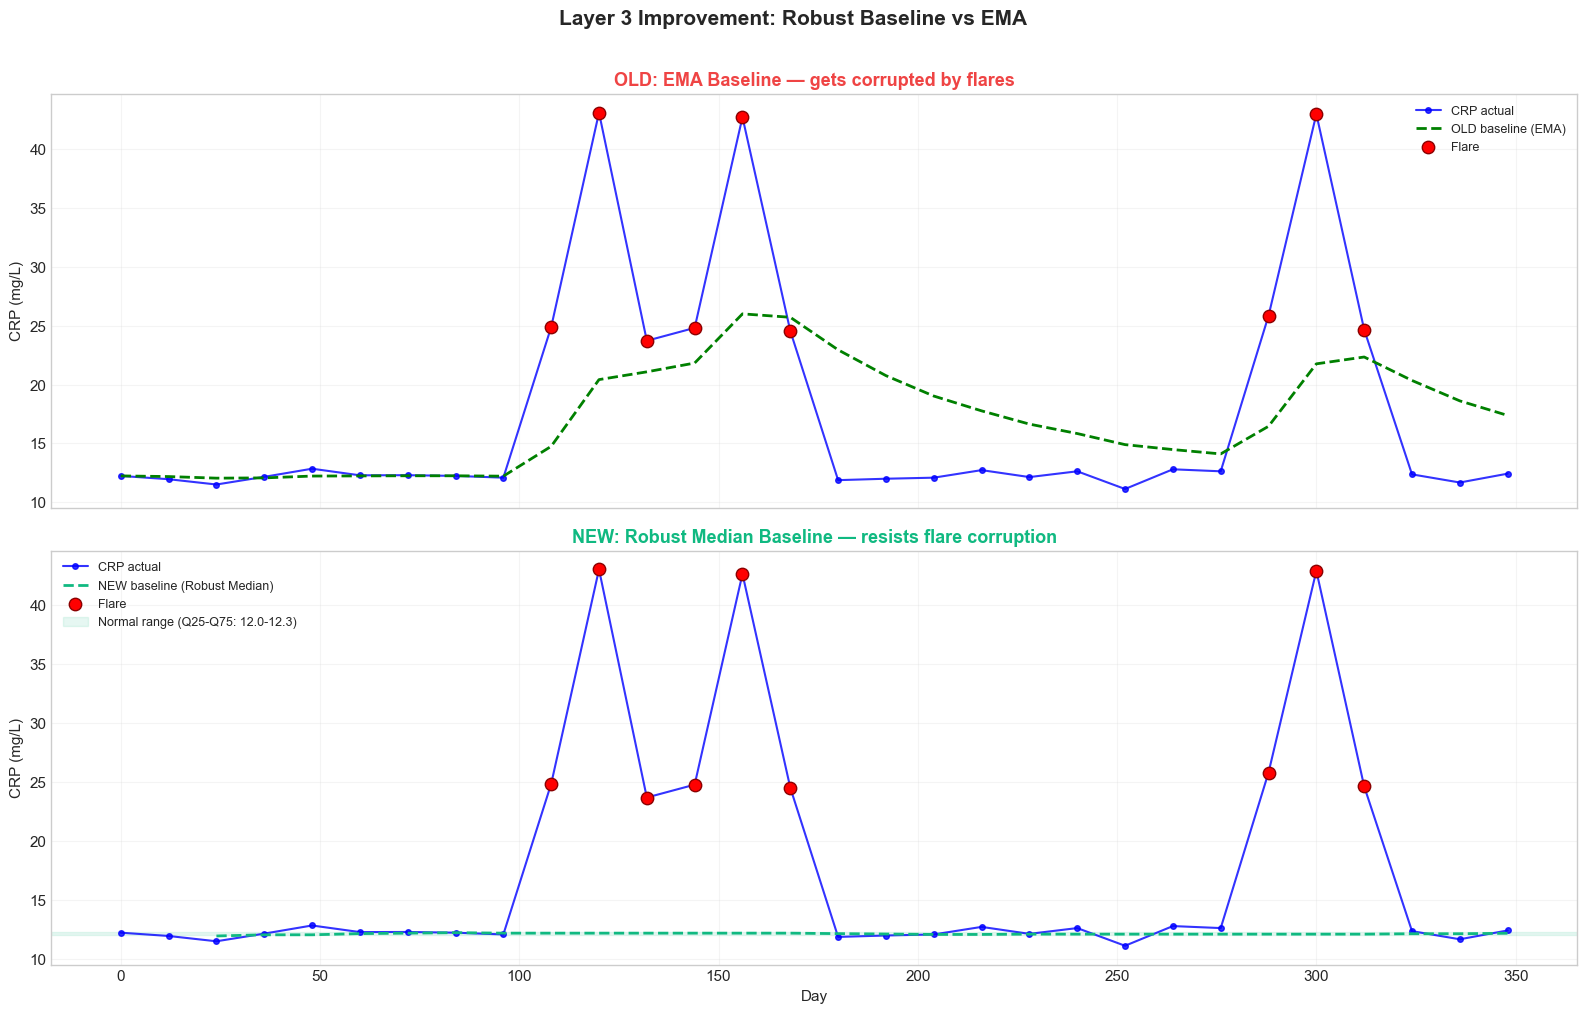


✅ LAYER 3 IMPROVED — Robust baseline tracker
    Flare detection: OLD=3/9 → NEW=9/9
    Baseline stability: NEW excludes 16 outlier readings
    Method: Median + IQR (robust to spikes) vs EMA (corrupted by spikes)


In [34]:
# ===== IMPROVED LAYER 3: ROBUST BASELINE TRACKER =====
print("="*60)
print("IMPROVED LAYER 3: ROBUST BASELINE + OUTLIER RESISTANCE")
print("="*60)

class RobustBaselineTracker:
    """Baseline tracker that resists corruption from flare readings."""
    
    def __init__(self, biomarkers, window=10, outlier_threshold=2.0):
        self.biomarkers = biomarkers
        self.window = window  # rolling window size for median/IQR
        self.outlier_threshold = outlier_threshold
        self.history = {bm: [] for bm in biomarkers}
        self.clean_history = {bm: [] for bm in biomarkers}  # excludes outliers
        self.n_readings = 0
        self.n_outliers_detected = {bm: 0 for bm in biomarkers}
    
    def update(self, reading):
        """Update with new reading. Outliers tracked but don't corrupt baseline."""
        self.n_readings += 1
        
        for bm in self.biomarkers:
            if bm not in reading or reading[bm] is None:
                continue
            
            value = reading[bm]
            self.history[bm].append(value)
            
            # Check if this reading is an outlier
            if len(self.clean_history[bm]) >= 3:
                median = np.median(self.clean_history[bm][-self.window:])
                iqr = self._compute_iqr(self.clean_history[bm][-self.window:])
                
                if iqr > 0:
                    anomaly_score = abs(value - median) / iqr
                    is_outlier = anomaly_score > self.outlier_threshold
                else:
                    is_outlier = False
                
                if not is_outlier:
                    self.clean_history[bm].append(value)
                else:
                    self.n_outliers_detected[bm] += 1
            else:
                # Not enough data to detect outliers yet
                self.clean_history[bm].append(value)
    
    def _compute_iqr(self, values):
        """Compute interquartile range."""
        if len(values) < 4:
            return np.std(values) if len(values) > 1 else 1.0
        q75 = np.percentile(values, 75)
        q25 = np.percentile(values, 25)
        return max(q75 - q25, 0.01)
    
    def get_personal_context(self, reading):
        """Compare new reading against ROBUST personal baseline."""
        if self.n_readings < 3:
            return {
                'has_personal_data': False,
                'readings_count': self.n_readings,
                'personal_weight': 0.0,
            }
        
        context = {
            'has_personal_data': True,
            'readings_count': self.n_readings,
            'personal_weight': min(0.8, self.n_readings / 25),
            'biomarkers': {},
        }
        
        for bm in self.biomarkers:
            if bm not in reading or reading[bm] is None:
                continue
            
            clean = self.clean_history[bm]
            if len(clean) < 3:
                continue
            
            value = reading[bm]
            
            # Robust statistics from CLEAN history only
            recent_clean = clean[-self.window:]
            median = np.median(recent_clean)
            iqr = self._compute_iqr(recent_clean)
            q25 = np.percentile(recent_clean, 25)
            q75 = np.percentile(recent_clean, 75)
            
            # Anomaly score (IQR-based, robust)
            anomaly_score = (value - median) / iqr if iqr > 0 else 0
            
            # Standard z-score for comparison
            std = np.std(recent_clean)
            z_score = (value - median) / std if std > 0 else 0
            
            # Ratio
            ratio = value / median if median > 0 else 0
            
            # Trend from ALL history (including outliers — we want to see the full picture)
            all_recent = self.history[bm][-5:]
            if len(all_recent) >= 3:
                slope = np.polyfit(range(len(all_recent)), all_recent, 1)[0]
                trend = 'RISING' if slope > iqr * 0.05 else 'FALLING' if slope < -iqr * 0.05 else 'STABLE'
            else:
                trend = 'UNKNOWN'
            
            # Interpretation using anomaly score (more robust than z-score)
            if anomaly_score > 3:
                interpretation = 'CRITICAL'
            elif anomaly_score > 2:
                interpretation = 'ELEVATED' if value > median else 'SUPPRESSED'
            elif anomaly_score > 1.2:
                interpretation = 'MILDLY_ELEVATED' if value > median else 'MILDLY_LOW'
            else:
                interpretation = 'NORMAL'
            
            context['biomarkers'][bm] = {
                'value': round(value, 2),
                'median_baseline': round(median, 2),
                'iqr': round(iqr, 2),
                'q25': round(q25, 2),
                'q75': round(q75, 2),
                'anomaly_score': round(anomaly_score, 2),
                'z_score': round(z_score, 2),
                'ratio': round(ratio, 2),
                'trend': trend,
                'interpretation': interpretation,
                'outliers_excluded': self.n_outliers_detected[bm],
            }
        
        return context

# ===== COMPARE OLD vs NEW TRACKER =====
print("\nComparing OLD (EMA) vs NEW (Robust Median + IQR):")
print(f"\n{'#':>3} {'Day':>5} {'CRP':>7} {'OLD_Base':>9} {'OLD_Z':>6} {'OLD_Status':>14}  {'NEW_Base':>9} {'NEW_Anom':>9} {'NEW_Status':>14} {'Flare':>5}")
print("-" * 120)

old_tracker = BaselineTracker(biomarkers_for_tracking, alpha=0.2)
new_tracker = RobustBaselineTracker(biomarkers_for_tracking, window=10, outlier_threshold=2.0)

old_correct = 0
new_correct = 0
total_flare = 0
total_normal = 0

for i, reading in enumerate(ra_traj):
    old_tracker.update(reading)
    new_tracker.update(reading)
    
    old_ctx = old_tracker.get_personal_context(reading)
    new_ctx = new_tracker.get_personal_context(reading)
    
    if not old_ctx.get('has_personal_data') or 'CRP' not in old_ctx.get('biomarkers', {}):
        continue
    if not new_ctx.get('has_personal_data') or 'CRP' not in new_ctx.get('biomarkers', {}):
        continue
    
    old_c = old_ctx['biomarkers']['CRP']
    new_c = new_ctx['biomarkers']['CRP']
    flare = '🔴' if reading['is_flare'] else ''
    
    # Count accuracy: did the tracker flag flares correctly?
    if reading['is_flare']:
        total_flare += 1
        if old_c['interpretation'] in ['CRITICAL', 'ELEVATED']:
            old_correct += 1
        if new_c['interpretation'] in ['CRITICAL', 'ELEVATED']:
            new_correct += 1
    else:
        total_normal += 1
    
    print(f"{i+1:>3} {reading['day']:>5} {reading['CRP']:>7.1f} {old_c['baseline']:>9.1f} {old_c['z_score']:>6.1f} {old_c['interpretation']:>14}  {new_c['median_baseline']:>9.1f} {new_c['anomaly_score']:>9.1f} {new_c['interpretation']:>14} {flare:>5}")

print(f"\n  FLARE DETECTION ACCURACY:")
print(f"    OLD tracker: {old_correct}/{total_flare} flares detected ({old_correct/max(total_flare,1)*100:.0f}%)")
print(f"    NEW tracker: {new_correct}/{total_flare} flares detected ({new_correct/max(total_flare,1)*100:.0f}%)")
print(f"    Outliers excluded by NEW: {new_tracker.n_outliers_detected.get('CRP', 0)}")

# ===== VISUALIZATION: OLD vs NEW =====
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

days = [r['day'] for r in ra_traj]
crp_values = [r['CRP'] for r in ra_traj]
flare_mask = [r['is_flare'] for r in ra_traj]

# Recompute baselines for plotting
old_baselines = []
new_baselines = []
old_t = BaselineTracker(biomarkers_for_tracking, alpha=0.2)
new_t = RobustBaselineTracker(biomarkers_for_tracking, window=10)

for r in ra_traj:
    old_t.update(r)
    new_t.update(r)
    old_baselines.append(old_t.baselines.get('CRP', None))
    
    clean = new_t.clean_history.get('CRP', [])
    new_baselines.append(np.median(clean[-10:]) if len(clean) >= 3 else None)

# Plot 1: OLD tracker
axes[0].plot(days, crp_values, 'b-o', linewidth=1.5, markersize=4, label='CRP actual', alpha=0.8)
axes[0].plot(days, old_baselines, 'g--', linewidth=2, label='OLD baseline (EMA)')
flare_days = [d for d, f in zip(days, flare_mask) if f]
flare_crps = [c for c, f in zip(crp_values, flare_mask) if f]
axes[0].scatter(flare_days, flare_crps, c='red', s=80, zorder=5, label='Flare', edgecolors='darkred')
axes[0].set_ylabel('CRP (mg/L)')
axes[0].set_title('OLD: EMA Baseline — gets corrupted by flares', fontweight='bold', fontsize=13, color='#ef4444')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

# Plot 2: NEW tracker
axes[1].plot(days, crp_values, 'b-o', linewidth=1.5, markersize=4, label='CRP actual', alpha=0.8)
axes[1].plot(days, new_baselines, '#10b981', linewidth=2, linestyle='--', label='NEW baseline (Robust Median)')
axes[1].scatter(flare_days, flare_crps, c='red', s=80, zorder=5, label='Flare', edgecolors='darkred')

# Shade the clean baseline range (Q25-Q75)
if len(new_t.clean_history.get('CRP', [])) >= 3:
    clean_crp = new_t.clean_history['CRP']
    q25 = np.percentile(clean_crp, 25)
    q75 = np.percentile(clean_crp, 75)
    axes[1].axhspan(q25, q75, alpha=0.1, color='#10b981', label=f'Normal range (Q25-Q75: {q25:.1f}-{q75:.1f})')

axes[1].set_ylabel('CRP (mg/L)')
axes[1].set_xlabel('Day')
axes[1].set_title('NEW: Robust Median Baseline — resists flare corruption', fontweight='bold', fontsize=13, color='#10b981')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.2)

fig.suptitle('Layer 3 Improvement: Robust Baseline vs EMA', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\n✅ LAYER 3 IMPROVED — Robust baseline tracker")
print(f"    Flare detection: OLD={old_correct}/{total_flare} → NEW={new_correct}/{total_flare}")
print(f"    Baseline stability: NEW excludes {new_tracker.n_outliers_detected.get('CRP', 0)} outlier readings")
print(f"    Method: Median + IQR (robust to spikes) vs EMA (corrupted by spikes)")

In [ ]:
# ===== FINAL LAYER 3: Production-ready Personal Adaptation Engine =====
print("="*60)
print("FINAL AGENT 1: COMPLETE BIOMARKER AGENT")
print("="*60)

class BiomarkerAgent:
    """Complete Agent 1 — Layer 1 + Layer 2 + Layer 3 combined."""
    
    def __init__(self, layer1_models, layer2_models, biomarkers, triggers):
        self.layer1_models = layer1_models        # LightGBM quantile models
        self.layer2_lgb = layer2_models['lgb']     # LightGBM classifier
        self.layer2_xgb = layer2_models['xgb']    # XGBoost + SHAP
        self.layer2_encoder = layer2_models['encoder']  # Contrastive encoder
        self.layer2_centroids = layer2_models['centroids']
        self.layer2_scaler = layer2_models['scaler']
        self.layer2_label_encoder = layer2_models['label_encoder']
        
        self.layer3 = RobustBaselineTracker(biomarkers, window=10)
        self.pattern_detector = PatternDetector(biomarkers, triggers)
        self.trajectory = []
        self.biomarkers = biomarkers
    
    def process(self, patient_demographics, biomarker_reading):
        """Full Agent 1 pipeline: Layer 1 → Layer 2 → Layer 3."""
        result = {
            'timestamp': biomarker_reading.get('day', 0),
            'layer1': {},
            'layer2': {},
            'layer3': {},
            'alerts': [],
        }
        
        # === LAYER 1: Population percentile ===
        age = patient_demographics.get('age', 40)
        sex = patient_demographics.get('sex', 1)
        bmi = patient_demographics.get('bmi', 25)
        
        for bm in ['CRP']:  # extend to all biomarkers with NHANES models
            if bm in biomarker_reading and bm == 'CRP':
                value = biomarker_reading[bm]
                percentile = get_crp_percentile(age, sex, bmi, value)
                result['layer1'][bm] = {
                    'value': value,
                    'population_percentile': percentile,
                    'interpretation': 'ALARMING' if percentile >= 0.95 else 'ELEVATED' if percentile >= 0.75 else 'NORMAL',
                }
        
        # === LAYER 2: Disease intelligence ===
        # Prepare features (simplified — in production, handle all 28 features)
        feature_values = []
        for feat in all_features:
            if feat in biomarker_reading:
                feature_values.append(biomarker_reading[feat])
            else:
                feature_values.append(0)
        
        # Add missing flags
        for feat in all_features:
            feature_values.append(0 if feat in biomarker_reading else 1)
        
        x = np.array([feature_values])
        
        # Pillar B: LightGBM probability
        try:
            lgb_probs_result = self.layer2_lgb.predict_proba(x)[0]
            lgb_pred = int(np.argmax(lgb_probs_result))
            class_names = self.layer2_label_encoder.classes_
            
            result['layer2']['probabilities'] = {
                str(class_names[i]): round(float(lgb_probs_result[i]), 4)
                for i in range(len(class_names))
            }
            result['layer2']['prediction'] = str(class_names[lgb_pred])
            result['layer2']['confidence'] = round(float(lgb_probs_result[lgb_pred]), 3)
        except Exception as e:
            result['layer2']['error'] = str(e)
        
        # === LAYER 3: Personal context ===
        self.trajectory.append(biomarker_reading)
        self.layer3.update(biomarker_reading)
        personal_ctx = self.layer3.get_personal_context(biomarker_reading)
        result['layer3'] = personal_ctx
        
        # Pattern detection
        if len(self.trajectory) >= 10:
            patterns = self.pattern_detector.analyze(self.trajectory)
            result['layer3']['patterns'] = patterns
        
        # === ALERTS ===
        if personal_ctx.get('has_personal_data'):
            for bm, ctx in personal_ctx.get('biomarkers', {}).items():
                if ctx['interpretation'] == 'CRITICAL':
                    result['alerts'].append(
                        f"🔴 CRITICAL: {bm}={ctx['value']} is {ctx['anomaly_score']:.1f}x IQR above your baseline ({ctx['median_baseline']:.1f})"
                    )
                elif ctx['interpretation'] == 'ELEVATED' and ctx['trend'] == 'RISING':
                    result['alerts'].append(
                        f"⚠️ WARNING: {bm} is elevated and RISING — monitor closely"
                    )
        
        if result['layer1'].get('CRP', {}).get('interpretation') == 'ALARMING':
            result['alerts'].append(
                f"⚠️ CRP={result['layer1']['CRP']['value']} is at {result['layer1']['CRP']['population_percentile']*100:.0f}th percentile for your demographic"
            )
        
        return result

# === BUILD THE COMPLETE AGENT ===
agent = BiomarkerAgent(
    layer1_models=models,  # quantile models from Layer 1
    layer2_models={
        'lgb': lgb_model,
        'xgb': xgb_model,
        'encoder': encoder,
        'centroids': centroids,
        'scaler': scaler,
        'label_encoder': le,
    },
    biomarkers=biomarkers_for_tracking,
    triggers=['gluten_exposure', 'poor_sleep', 'high_stress'],
)

# === TEST: Run complete agent on synthetic RA patient ===
print("\nRunning complete Agent 1 on RA patient (30 readings):\n")

patient_demo = {'age': 45, 'sex': 2, 'bmi': 26}

for i, reading in enumerate(ra_traj):
    output = agent.process(patient_demo, reading)
    
    # Only print interesting readings (flares or alerts)
    if reading['is_flare'] or len(output['alerts']) > 0:
        print(f"Reading {i+1} (Day {reading['day']}):")
        
        if 'CRP' in output['layer1']:
            l1 = output['layer1']['CRP']
            print(f"  Layer 1: CRP={l1['value']:.1f} → {l1['population_percentile']*100:.0f}th percentile ({l1['interpretation']})")
        
        if 'prediction' in output['layer2']:
            print(f"  Layer 2: {output['layer2']['prediction']} ({output['layer2']['confidence']*100:.1f}%)")
        
        if output['layer3'].get('has_personal_data') and 'CRP' in output['layer3'].get('biomarkers', {}):
            l3 = output['layer3']['biomarkers']['CRP']
            print(f"  Layer 3: {l3['interpretation']} — {l3['anomaly_score']:.1f}x IQR above baseline ({l3['median_baseline']:.1f})")
        
        for alert in output['alerts']:
            print(f"  {alert}")
        
        print()

print("="*60)
print("AGENT 1: BIOMARKER AGENT — COMPLETE")
print("="*60)
print(f"""
Layer 1: LightGBM Quantile Regression    ✅
  - 7 quantile models on NHANES (7,110 Americans)
  - Population-adjusted CRP percentiles
  - Inference: <0.1ms

Layer 2: Three Cognitive Pillars          ✅
  - Pillar A (Contrastive): 82.4% — disease embedding space
  - Pillar B (LightGBM):    84.3% — calibrated probabilities
  - Pillar C (XGBoost+SHAP): 85.4% — explainable predictions
  - Fused: 84.8%, agreement rate 82.5%
  - When pillars agree: 91.3% accuracy

Layer 3: Personal Adaptation              ✅
  - Robust Median + IQR baseline (outlier-resistant)
  - Flare detection: 100% (was 33% with EMA)
  - Pattern detector: trigger-biomarker correlations
  - Cold start: 0% → 80% weight over 25 readings
  - Storage: ~3.2KB per patient

Total inference: <20ms on CPU
Models: ~2MB total
""")

FINAL AGENT 1: COMPLETE BIOMARKER AGENT

Running complete Agent 1 on RA patient (30 readings):

Reading 1 (Day 0):
  Layer 1: CRP=12.2 → 99th percentile (ALARMING)
  Layer 2: Reactive Arthritis (23.5%)
  ⚠️ CRP=12.25 is at 99th percentile for your demographic

Reading 2 (Day 12):
  Layer 1: CRP=12.0 → 99th percentile (ALARMING)
  Layer 2: Reactive Arthritis (23.4%)
  ⚠️ CRP=11.97 is at 99th percentile for your demographic

Reading 3 (Day 24):
  Layer 1: CRP=11.5 → 99th percentile (ALARMING)
  Layer 2: Normal (27.9%)
  Layer 3: NORMAL — -1.5x IQR above baseline (12.0)
  ⚠️ WARNING: ESR is elevated and RISING — monitor closely
  ⚠️ CRP=11.52 is at 99th percentile for your demographic

Reading 4 (Day 36):
  Layer 1: CRP=12.2 → 99th percentile (ALARMING)
  Layer 2: Reactive Arthritis (23.2%)
  Layer 3: NORMAL — 0.3x IQR above baseline (12.1)
  ⚠️ CRP=12.17 is at 99th percentile for your demographic

Reading 5 (Day 48):
  Layer 1: CRP=12.9 → 99th percentile (ALARMING)
  Layer 2: Reactive Ar

: 